# Read the PDF

In [1]:
# libraries for text cleaning
%pip install nltk
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords as sw
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer

# PDF reader
%pip install pdfplumber
import pdfplumber

# convert date string to datetime format
from datetime import datetime

# data cleaning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# file path checking
import os

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/henrytran/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/henrytran/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/henrytran/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# We should use this code
# this is the text extracted from the first 3 pages extracted from the
def raw_data_extraction(input_pdf):
    # take the pdf as an input and return the whole pdf as text
    raw_input=""
    with pdfplumber.open(input_pdf) as pdf:
        for page in pdf.pages:
            raw_input+=(page.extract_text() or "") + "\n"
    return raw_input

def article_extraction(raw_input):
    article=""
    details=""
    article_idx=0
    article_dict={}
    details_dict={}
    article_status=False # mark the start of the article
    details_status=False
    for row in raw_input.lower().split('\n'):
        if row=='full text':
            article_status=True
            article_idx+=1
            continue
        if article_status:
            if row=='details':
                article_status=False
                details_status=True
                article_dict[article_idx] = article
                article=""
                continue
            article+=row+" "
        if details_status:
            if row=='links':
                details_status=False
                details_dict[article_idx]=details
                details=""
                continue
            details+=row+'\n'
    return article_dict, details_dict

def clean_article(article):
    lemmatizer=WordNetLemmatizer()
    desc = re.sub(r'\([^)]*\)', '', article)
    sent_desc =sent_tokenize(desc)
    sww=set(sw.words())
    abstraction = []
    for sent in sent_desc:
        # normalise U.S., US, USA, U.S.A., etc. all to "america" (for classification)
        sent = re.sub(r"\b(?:u\.?\s*s\.?|usa|u\.?\s*s\.?\s*a\.?)\b", "america", sent, flags=re.IGNORECASE)
        # normalise to lowercase and only letters and numbers
        tokens = re.sub(r"[^a-z0-9]+", " ", sent.lower())
        words = word_tokenize(tokens)
        remaining_words = [word for word in words if word not in sww]
        if remaining_words:
            lemmatised_words=[]
            for word in remaining_words:
                lemmatised_word=lemmatizer.lemmatize(word)
                lemmatised_words.append(lemmatised_word)
            abstraction.append(lemmatised_words)
    final_doc=""
    for sent in abstraction[:-1]:
        for word in sent:
            final_doc+=word+" "
    return final_doc # remove the name of the writer

def clean_detail(detail):
    year=None
    date=None
    article_id=""
    for row in detail.split('\n'):
        # need to make this condition smarter
        if row.split(":")[0]=="proquest document id" or row.split(":")[0]=="proquestdocument id" or row.split(":")[0]=="proquestdocumentid" or row.split(":")[0]=="proquest documentid":
            article_id=row.split(":")[1].strip().split(" ")
            if len(article_id)>1:
                new_id=""
                for part in article_id:
                    new_id+=part
                article_id=[new_id]
            continue
        #if row.split(":")[0]=="publication year":
            #year = str(row.split(":")[1].strip())
            #print(year)
        if row.split(":")[0]=="publication date":
            raw_date=row.split(":")[1].split(",")[0].strip().split(" ")
            raw_year=row.split(":")[1].split(",")[1].strip().split(" ")
            raw_date1=""
            raw_date2=""
            for value in raw_date: # add date
                raw_date1+=value
            for value in raw_year: # add year
                raw_date1+=value
            if len(raw_date1)==8:
                raw_date2+=raw_date1[:3]+" "+raw_date1[3]+" "+raw_date1[4:]
            if len(raw_date1)==9:
                raw_date2+=raw_date1[:3]+" "+raw_date1[3:5]+" "+raw_date1[5:]
            #full_raw_date= raw_date2 + " "+ year
            format_date= "%b %d %Y"           
            date = datetime.strptime(raw_date2, format_date)
    return (date.date() if date else None), article_id
    



# To find the unique words and count for the 222 articles

1-3 grams

In [ ]:
raw_input222 = raw_data_extraction('ProQuestDocuments-2025-08-16_1_fiscalpolicy_last12.pdf')

In [ ]:
article222_dict, details222_dict = article_extraction(raw_input222)

#print(details222_dict[1])
clean_detail(details222_dict[1])
#for key in article222_dict.keys():
 #   cleaned_article222 = clean_article(article222_dict[key])
 #   print(cleaned_article222)

#clean_article(article222_dict[1])

In [ ]:
from nltk.util import ngrams
from collections import Counter

# cleaned tokens 
all_tokens = []
for key, article in article222_dict.items():
    cleaned_article = clean_article(article)   
    tokens = cleaned_article.split()
    all_tokens.extend(tokens)

# remove token that are only numbers
def is_word(token):
    # keep only tokens with letters (ignore pure numbers)
    return re.match(r'^[A-Za-z]+$', token)

filtered_tokens = [tok for tok in all_tokens if is_word(tok)]

# 1/2/3 grams
ngram_counts = Counter()
for n in [1, 2, 3]:
    ngrams_list = [" ".join(ng) for ng in ngrams(filtered_tokens, n)]
    ngram_counts.update(ngrams_list)

# top n phrases (500)
top_phrases = ngram_counts.most_common(500)

# results
print("Number of unique phrases (1–3 grams):", len(ngram_counts))
print("Top 500 phrases:\n")
for phrase, count in top_phrases:
    print(f"{phrase}: {count}")

 
# Convert the list of tuples into a df
top_phrases_df = pd.DataFrame(top_phrases, columns=["phrase", "count"])

# esxport to csv
top_phrases_df.to_csv("top_phrases.csv", index=False)

# Create the set of fiscal policy related words

In [ ]:
# terms_categories = {
#     # Core fiscal categories
#     'tax': ['tax cuts','tax increases','tax rates','taxes','tax legislation','income taxes'],
    
#     'budget_debt': ['budget deficits','federal budget','deficit financing','national debt',
#                     'borrowing','federal funding','government debt'],
    
#     'spending_social_programs': ['defense spending','social security','medicare','stimulus',
#                                 'federal spending'],

#     'fiscal_policy': ['fiscal policy','fiscal stimulus','fiscal reform'],

#     'tariffs_trade': ['tariffs','trade policy','trade disputes','international trade',
#                     'trade relations','exports','supply chains','border security',
#                     'immigration policy','immigration','deportation',],

#     # America filter
#     'america': ['america','american',
#         "alabama","alaska","arizona","arkansas","california","colorado",
#         "connecticut","delaware","florida","georgia","hawaii","idaho",
#         "illinois","indiana","iowa","kansas","kentucky","louisiana",
#         "maine","maryland","massachusetts","michigan","minnesota",
#         "mississippi","missouri","montana","nebraska","nevada",
#         "new hampshire","new jersey","new mexico","new york",
#         "north carolina","north dakota","ohio","oklahoma","oregon",
#         "pennsylvania","rhode island","south carolina","south dakota",
#         "tennessee","texas","utah","vermont","virginia","washington",
#         "west virginia","wisconsin","wyoming"]
# }


In [ ]:
#ADD NEW TERMS CATEGORY HERE
groups = {
    'fiscal_terms':{
        'revenue_taxation': ['tax', 'taxation', 'taxed', 'subsidies', 'subsidy', 'public sector revenue', 'import tariffs', 'import duty', 'trade act'],

        'government_spending': ['government spending', 'federal budget', 'defense spending', 'military spending', 
                                'public investment', 'social protection', 'healthcare expenditure', 'medical expenditure', 'pension reform'],
        
        'debt_borrowing': ['federal debt', 'public debt', 'national debt',
                            'debt ceiling', 'sovereign debt', 'government bond', 
                            'sovereign yield', 'borrowing', 'debt sustainability', 'debt default'],
        
        'budget_balance': ['budget deficit' , 'fiscal stimulus', 'balanced budget', 'budget gap', 
                            'national deficit', 'fiscal policy', 'public finance', 'debt consolidation',
                            'budget battle', 'fiscal footing', 'gramm-rudman'],
        
        'social_safety_net': ['social security', 'entitlement spending', 'social safety net', 'pension expenditure', 'medical care expenditure',
                                'medicaid', 'medicare', 'government welfare', 'food stamps', 'eitc']
    },

    'trade_terms':{
        'trade_policy': ['import tariffs', 'import duty', 'import barrier', 'government subsidies', 'government subsidy', 
                        'wto', 'world trade organization', 'trade treaty', 'trade agreement', 'trade policy', 'trade act', 
                        'doha round', 'uruguay round', 'gatt, dumping']
    },

    'america':{
        'america': ['america','american',
        
                    'white house', 'capitol hill', 'congress', 'senate', 'federal reserve', 'the fed', 'treasury department',

                    "alabama","alaska","arizona","arkansas","california","colorado",
                    "connecticut","delaware","florida","georgia","hawaii","idaho",
                    "illinois","indiana","iowa","kansas","kentucky","louisiana",
                    "maine","maryland","massachusetts","michigan","minnesota",
                    "mississippi","missouri","montana","nebraska","nevada",
                    "new hampshire","new jersey","new mexico","new york",
                    "north carolina","north dakota","ohio","oklahoma","oregon",
                    "pennsylvania","rhode island","south carolina","south dakota",
                    "tennessee","texas","utah","vermont","virginia","washington",
                    "west virginia","wisconsin","wyoming"]
    }
}


# Match the terms and categories with the documents

In [ ]:
# this for the categoires of fiscal_terms (not list)
# lemmatizing the set of fiscal words so they match the lemmatized articles

def lemmatize_string(string, lemmatizer):
    return " ".join(lemmatizer.lemmatize(w) for w in string.split())
    
def lemmatize_categories(categories, lemmatizer):
    lemmatized = {}
    for key, terms in categories.items():
        lemmatized[key] = [lemmatize_string(term, lemmatizer) for term in terms]
    return lemmatized

lemmatizer = WordNetLemmatizer()
terms_categories_lemmatized = lemmatize_categories(terms_categories, lemmatizer) # keep this

In [ ]:
# how many rules do want want to match

# match the fiscal term groups to the document
def count_matching_category(terms_categories, document):
    # this function will count number of terms in fiscal policy categories and classified whether a new is fical_policy related or not
    terms_list=[word for category in terms_categories.values() for word in category]
    terms_count={}
    is_fiscal=False
    for term in terms_list:
        term_count=document.count(term)
        if term_count>0:
            for key in terms_categories.keys():
                if term in terms_categories[key]:
                    terms_count[key]=terms_count.get(key,0)+term_count
    if len(terms_count.keys())>=2 and 'america' in terms_count.keys(): # >= 2 means 2 categories but one is 'america'
        is_fiscal=True
    return terms_count, is_fiscal # return the boolean values for terms_count.keys()>=3

#terms_count, is_fiscal=count_matching_category(terms_categories_lemmatized,doc1)
#terms_count, is_fiscal

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_string(string, lemmatizer):
    return " ".join([lemmatizer.lemmatize(w.lower()) for w in string.split()])


def lemmatize_groups(groups, lemmatizer):
    new_groups={}
    for group_key, cats in groups.items():
        new_groups[group_key]={}
        for cat_key, terms in cats.items():
                lemmatized_terms = [lemmatize_string(term, lemmatizer) for term in terms]
                new_groups[group_key][cat_key] = lemmatized_terms
    return new_groups

def count_matching_terms(input_groups, input_document):
    # variable declaration
    document=input_document.lower()
    groups=input_groups
    groups_count={}
    is_fiscal=False
    is_trade=False

    # count occurences for each group
    for group_key, categories in groups.items():
        for category_key, terms in categories.items():
            for term in terms:
                count=document.count(term)
                if count>0:
                    groups_count[group_key]= groups_count.get(group_key,0)+count

    if len(groups_count.keys())>=2 and 'america' in groups_count.keys():
        if 'fiscal_terms' in groups_count.keys() and groups_count['fiscal_terms']>=1:
            is_fiscal=True
        if 'trade_terms' in groups_count.keys() and groups_count['trade_terms']>=1:
            is_trade=True
    return groups_count, is_fiscal, is_trade


In [ ]:
groups_count, is_fiscal, is_trade=count_matching_terms(groups,article222_dict[1])
groups_count, is_fiscal, is_trade

# Make the dataframe to store the data

In [ ]:
# Keep for now, will delete once process_articles works
# def full_pipeline(input_pdf):
#     raw_input=raw_data_extraction(input_pdf)
#     article_dict, details_dict = article_extraction(raw_input)
#     column_names =['article_id', 'date', 'is_fiscal_article', 'has_tariff']
#     fiscal_articles_df=pd.DataFrame(columns=column_names)
    
#     for key in article_dict.keys():
#         cleaned_article=clean_article(article_dict[key])
#         date, article_id=clean_detail(details_dict[key])
#         #print(article_id)
#         #number_matching_words = count_matching_words(terms_categories_lemmatized, cleaned_article) # do we need this?
#         number_matching_terms, is_fiscal=count_matching_category(terms_categories_lemmatized,cleaned_article)
#         # tariff flag code
#         has_tariff = any(term in cleaned_article for term in terms_categories_lemmatized["tariffs_trade"])
#         #print(fiscal_articles_df['article_id'].values)


#         if article_id[0] not in fiscal_articles_df['article_id'].values: # checked for duplicated articles
#             fiscal_articles_df.loc[key]=[article_id[0], date, is_fiscal, has_tariff]
#     return fiscal_articles_df   
    

In [ ]:
# using gglob to collect all of the PDF files in /fiscal_policy_index/data_articles
import glob

pdf_wsj = glob.glob("data_articles/*.pdf") # all collected pdf
print("There are", len(pdf_wsj), "Wall Street Journal PDFs")

In [ ]:
import hashlib
import os
import json

MANIFEST_FILE = "processed_pdf.json"

def get_file_hash(filepath):
    """Generates a unique ID for the file based on its content."""
    hasher = hashlib.md5()
    with open(filepath, 'rb') as f:
        buf = f.read()
        hasher.update(buf)
    return hasher.hexdigest()

def get_new_files(directory, manifest):
    """Returns only files that haven't been hashed in the manifest yet."""
    new_files = []
    for filename in os.listdir(directory):
        if filename.endswith(".pdf"):
            path = os.path.join(directory, filename)
            f_hash = get_file_hash(path)
            if f_hash not in manifest:
                new_files.append((path, f_hash))
    return new_files

# --- MAIN LOGIC ---
# 1. Load existing manifest
if os.path.exists(MANIFEST_FILE):
    with open(MANIFEST_FILE, 'r') as f:
        manifest = json.load(f)
else:
    manifest = {}

# 2. Identify only new PDFs
new_pdfs = get_new_files("data_articles/", manifest)

# 3. Process them
for path, f_hash in new_pdfs:
    print(f"Processing new file: {path}")
    # Run your extraction and classification code here...
    
    # 4. Update manifest after successful processing
    manifest[f_hash] = path 

# 5. Save updated manifest
with open(MANIFEST_FILE, 'w') as f:
    json.dump(manifest, f)

In [ ]:
def process_articles(collected_pdf, article_csv_filepath, groups, manifest_path="manifest.json"):
    # check the manifest json file and create document hash if needed
    if os.path.exists(manifest_path):
        with open(manifest_path, 'r') as f:
            processed_hashes = json.load(f)
    else:
        processed_hashes = {}

    # load existing articles_csv_filepath
    if os.path.exists(article_csv_filepath):
        article_df=pd.read_csv(article_csv_filepath)
        existing_id=set(article_df['article_id'].tolist())
    else:
        article_df=pd.DataFrame()
        existing_id=set()
        column_names = ['article_id', 'date', 'is_fiscal_article', 'is_trade_article']
        article_df = pd.DataFrame(columns=column_names).astype({
                                            'article_id': 'object', 
                                            'date': 'object'})
    
    # process all collected_pdf
    for pdf in collected_pdf:
        file_hash = get_file_hash(pdf)
        
        if file_hash in processed_hashes: 
            print(f"Skipping {pdf} - already processed.")
            continue

        print("Processing {}".format(pdf))
        try:
            raw_input=raw_data_extraction(pdf)
            article_dict, details_dict = article_extraction(raw_input)
            
            for key in article_dict.keys():
                cleaned_article=clean_article(article_dict[key])
                date, article_id=clean_detail(details_dict[key])
                # check if article_id in the pdf is already existed in csv file
                if str(article_id[0]) not in existing_id:
                    # count the matching terms for clssification
                    number_matching_terms, is_fiscal, is_trade=count_matching_terms(groups,cleaned_article)
                    # tariff flag code
                    #has_tariff = any(term in cleaned_article for term in terms_categories_lemmatized["tariffs_trade"])
                    article_df.loc[len(article_df)]=[str(article_id[0]), date, is_fiscal, is_trade] # remove 'has_tariff'
                    existing_id.add(str(article_id[0]))
                else:
                    continue
            processed_hashes[file_hash] = pdf # store hash and filename into the manifest
        
        except Exception as e:
            print(f"Failed to process {pdf}: {e}")
            continue

    # return the result
    article_df.to_csv(article_csv_filepath, index=False)
    with open(manifest_path, 'w') as f:
        json.dump(processed_hashes, f) # update new manifest json file
    return article_df

In [ ]:
process_articles(pdf_wsj, '/Users/henrytran/Documents/GitHub/Data_Science_Capstone_Project_11/fiscal_policy_index/wsj_articles.csv', groups)

# Fiscal News Index Calculation

In [3]:
# read all articles instead of using local variable assignment of wsj_df
wsj_df = pd.read_csv("wsj_articles.csv", parse_dates=["date"])

wsj_df.head(10)

,article_id,date,is_fiscal_article,is_trade_article
0,3239236707,2025-08-14,True,False
1,3239232132,2025-08-14,False,False
2,3239232131,2025-08-14,False,False
3,3239232127,2025-08-14,False,False
4,3239232123,2025-08-14,False,False
5,3239232119,2025-08-14,False,True
6,3239232113,2025-08-14,True,False
7,3239232109,2025-08-14,True,False
8,3239232107,2025-08-14,True,False
9,3239232106,2025-08-14,False,True


In [30]:
# Total number of articles per month
monthly_counts = wsj_df.groupby(wsj_df['date'].dt.to_period('M')).size()
monthly_counts = pd.DataFrame(monthly_counts).reset_index()
#pd.DataFrame(monthly_counts).reset_index()

In [9]:
# Number of fiscal and tariff articles by the end of each months
fiscal_trade_counts=wsj_df.groupby(pd.Grouper(key='date', axis=0, freq='ME')).sum().reset_index()[['date', 'is_fiscal_article', 'is_trade_article']]
fiscal_trade_counts

,date,is_fiscal_article,is_trade_article
0,2022-08-31,55,4
1,2022-09-30,84,4
2,2022-10-31,116,7
3,2022-11-30,84,4
4,2022-12-31,102,10
5,2023-01-31,94,9
6,2023-02-28,82,5
7,2023-03-31,122,14
8,2023-04-30,88,7
9,2023-05-31,114,7


In [14]:
# FULL CALCULATION - FISCAL INDEX
## Step 1: Raw count
raw_count = fiscal_trade_counts['is_fiscal_article'] / monthly_counts.iloc[0] # rate of fiscal news

## Step 2: Calculate Volatility - Standard deviation values of all articles for the whole period in the dataframe
sigma = np.std(raw_count)
sigma # standard deviation of all time

## Step 3: Standardising the values - Volatility rate
monthly_voltality = raw_count / sigma 
monthly_voltality # fiscal news rate monthly/ standard deviation of all time

## Step 4: Mean Scaling
mean_scaling = np.mean(monthly_voltality) 
mean_scaling # average rate of difference

## Step 5: Normalise to scale 100
fiscal_index = monthly_voltality * (100/mean_scaling)
fiscal_index # normalised to scale 100

## Step 6: Merge as dataframe for visualisation
column_names =['date', 'index']
fiscal_index_df=pd.DataFrame(columns=column_names)
fiscal_index_df['date'] = fiscal_trade_counts['date'].dt.strftime("%Y-%m")
fiscal_index_df['index'] = fiscal_index
fiscal_index_df

fiscal_index_df.to_csv('fiscal_index.csv')


<Axes: xlabel='date'>

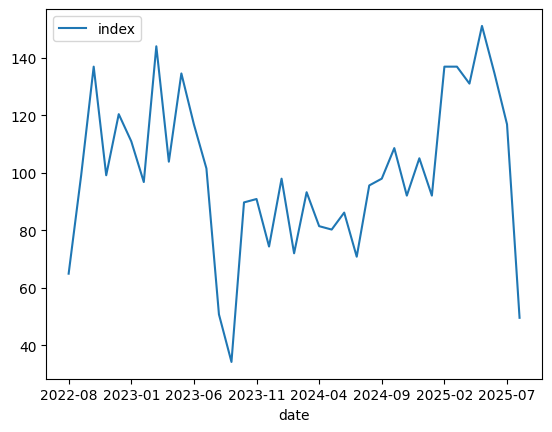

In [7]:
# quick visualisation
fiscal_index_df.plot(x='date') # need to make this visual better

In [13]:
# FULL CALCULATION - TRADE INDEX
## Step 1: Raw count
raw_count = fiscal_trade_counts['is_trade_article'] / monthly_counts.iloc[0] # rate of fiscal news

## Step 2: Calculate Volatility - Standard deviation values of all articles for the whole period in the dataframe
sigma = np.std(raw_count)
sigma # standard deviation of all time

## Step 3: Standardising the values - Volatility rate
monthly_voltality = raw_count / sigma 
monthly_voltality # fiscal news rate monthly/ standard deviation of all time

## Step 4: Mean Scaling
mean_scaling = np.mean(monthly_voltality) 
mean_scaling # average rate of difference

## Step 5: Normalise to scale 100
trade_index = monthly_voltality * (100/mean_scaling)
trade_index # normalised to scale 100

## Step 6: Merge as dataframe for visualisation
column_names =['date', 'index']
trade_index_df=pd.DataFrame(columns=column_names)
trade_index_df['date'] = fiscal_trade_counts['date'].dt.strftime("%Y-%m")
trade_index_df['index'] = trade_index
trade_index_df

trade_index_df.to_csv('trade_index.csv')

<Axes: xlabel='date'>

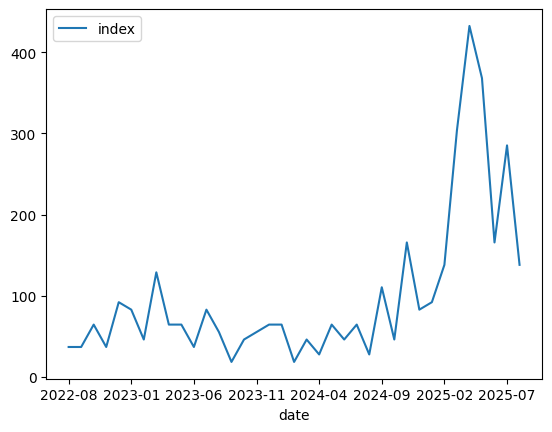

In [12]:
# quick visualisation
trade_index_df.plot(x='date') # need to make this visual better

# DO NOT TOUCH THE BELOW CODE

In [ ]:
# ORIGINAL CALCULATION, DO NOT CHANGE THIS PART
# Experimenting to plot fiscal score, fiscal score tariff included, fiscal score no tariff

# sort from oldest to latest
wsj_df = wsj_df.sort_values(by='date', ascending=True)

# ---- Daily Fiscal Index Scores ----
wsj_fpi = wsj_df.groupby("date").agg(
    total_articles=("article_id", "count"),
    fiscal_articles=("is_fiscal_article", "sum"),
    tariff_fiscal_articles=("has_tariff", "sum")   # tariff flagged articles
).reset_index()

# non-tariff fiscal articles = fiscal - tariff
wsj_fpi["non_tariff_fiscal_articles"] = (
    wsj_fpi["fiscal_articles"] - wsj_fpi["tariff_fiscal_articles"]
)

# rates
wsj_fpi["rate"] = wsj_fpi["fiscal_articles"] / wsj_fpi["total_articles"] # rate of fiscal articles
wsj_fpi["tariff_rate"] = wsj_fpi["tariff_fiscal_articles"] / wsj_fpi["total_articles"]
wsj_fpi["non_tariff_rate"] = wsj_fpi["non_tariff_fiscal_articles"] / wsj_fpi["total_articles"]

# normalize each (mean = 100)
wsj_fpi["fiscal_policy_index"] = wsj_fpi["rate"] / wsj_fpi["rate"].mean() * 100
wsj_fpi["tariff_fiscal_index"] = wsj_fpi["tariff_rate"] / wsj_fpi["tariff_rate"].mean() * 100
wsj_fpi["non_tariff_fiscal_index"] = wsj_fpi["non_tariff_rate"] / wsj_fpi["non_tariff_rate"].mean() * 100


In [ ]:
# wsj_fpi df
wsj_fpi.head(5)

In [ ]:
# export to csv - daily rate
wsj_fpi.to_csv("wsj_articles_scores.csv", index=False)

# Visualisation

In [ ]:
# open csv to do visualiation
#wsj_fpi = pd.read_csv("wsj_articles_scores.csv", parse_dates=["date"])

In [18]:
print("Start month range: {}".format(fiscal_index_df['date'].iloc[0]))
print("End month range: {}".format(fiscal_index_df['date'].iloc[-1]))

Start month range: 2022-08
End month range: 2025-08


In [31]:
# Start and end date 
start_date_str='2022-09' # please enter your date here in format 'yyyy-mm'
start_date=pd.to_datetime(start_date_str)
end_date_str='2025-07' # please enter your date here in format 'yyyy-mm'
end_date=pd.to_datetime(end_date_str)

# convert datetime type in the data
fiscal_index_df['date'] = pd.to_datetime(fiscal_index_df['date'])
trade_index_df['date'] = pd.to_datetime(trade_index_df['date'])

# mask the time filter
mask = (fiscal_index_df['date'] >= start_date) & (fiscal_index_df['date'] <= end_date)
fiscal_index_df1 = fiscal_index_df.loc[mask]
trade_index_df1 = trade_index_df.loc[mask]
fiscal_trade_counts1 = fiscal_trade_counts[mask]
monthly_counts1=monthly_counts[mask]

In [34]:
# summary information of the specified date
print("Data summary from {} to {}:".format(start_date_str, end_date_str))
print("Total number of fiscal policy news: {}".format(fiscal_trade_counts['is_fiscal_article'].sum()))
print("Total number of news is: {}".format(monthly_counts1[0].sum()))
print(round((fiscal_trade_counts['is_fiscal_article'].sum() / monthly_counts1[0].sum()) * 100, 2),'%', 
      "of articles are fiscal articles")

Data summary from 2022-09 to 2025-07:
Total number of fiscal policy news: 3134
Total number of news is: 15574
20.12 % of articles are fiscal articles


# DO NOT TOUCH THE BELOW CODE

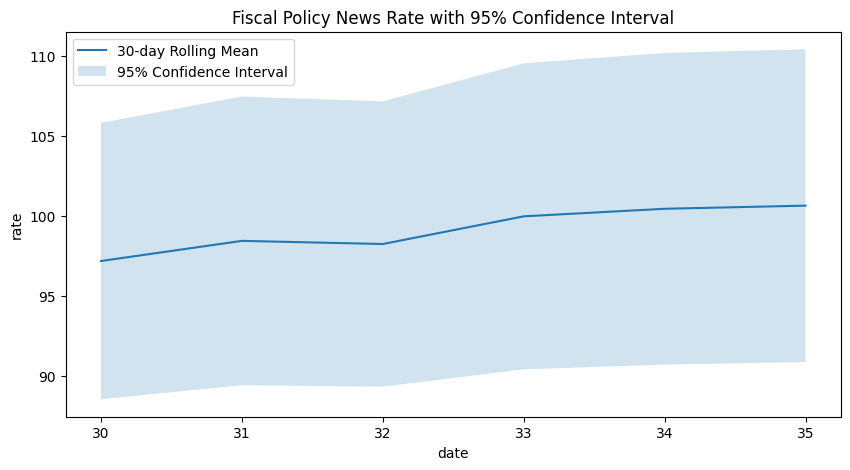

In [36]:
# 30 days rolling
#wsj_fpi = wsj_fpi.set_index('date')
#wsj_fpi['rate'].rolling(30).mean().plot(figsize=(10,5))

# calculate 95% confident intervals
window=30
z=1.96

rolling_mean=fiscal_index_df1['rate'].rolling(window).mean() # want to search by the date (start and end date)
rolling_std=fiscal_index_df1['rate'].rolling(window).std() 

upper=rolling_mean+z*(rolling_std/np.sqrt(window))
lower=rolling_mean-z*(rolling_std/np.sqrt(window))

# plot the visual
plt.figure(figsize=(10, 5))
plt.plot(rolling_mean, label='30-day Rolling Mean')
plt.fill_between(
    rolling_mean.index,
    lower,
    upper,
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.title("Fiscal Policy News Rate with 95% Confidence Interval")
plt.xlabel('date')
plt.ylabel('rate')
plt.legend()
plt.show()


In [ ]:
#wsj_fpi1.columns

In [ ]:
# daily fiscal policy index
#wsj_fpi = wsj_fpi.set_index('date')
wsj_fpi1.plot(x="date", y="fiscal_policy_index", kind="line", 
    figsize=(12,6), rot=90, yticks=range(0, 200, 50), 
    title="Fiscal Policy Index Over Time")

In [ ]:
# with a 7 day rolling average (smoother)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(wsj_fpi1["date"], wsj_fpi1["fiscal_policy_index"], label="Daily Index", alpha=0.5)
plt.plot(wsj_fpi1["date"], wsj_fpi1["fiscal_policy_index"].rolling(7).mean(), 
         label="7-day Rolling Avg", linewidth=2, color="red")

plt.title("Fiscal Policy Index Over Time")
plt.xlabel("Date")
plt.ylabel("Index (Normalized, mean=100)")
plt.ylim(0, 350)
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Plot with 7-day rolling average 
plt.figure(figsize=(12,6))

plt.plot(
    wsj_fpi1["date"], wsj_fpi1["fiscal_policy_index"].rolling(30).mean(),
    label="Fiscal Index (30-day Avg)", linewidth=2
)
plt.plot(
    wsj_fpi1["date"], wsj_fpi1["tariff_fiscal_index"].rolling(30).mean(),
    label="Tariff Fiscal Index (30-day Avg)", linewidth=2
)
plt.plot(
    wsj_fpi1["date"], wsj_fpi1["non_tariff_fiscal_index"].rolling(30).mean(),
    label="Non-Tariff Fiscal Index (30-day Avg)", linewidth=2
)

plt.title("Fiscal Policy Index: Fiscal vs Tariff vs Non-Tariff")
plt.xlabel("Date")
plt.ylabel("Index (Normalized, mean=100)")
plt.legend()
plt.show()


# NOTES ALL WE HAVE TO DO
- Add the date filter options to show the visualisation based on the date
- With the link: https://www.treasurydirect.gov/TA_WS/securities/jqsearch - can create a python file to select the security term and extract as an excel file. 

# Dashboard 
A. fiscal news: number of news, tarriff, non-tarriff news. The the index for 95% confidence intervals. 

B. Treasury Auction information: we can do visualisation based on security type, timeframe, security terms